In [40]:
import requests
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
from dotenv import load_dotenv
import os
import time
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from scipy.sparse import hstack

load_dotenv()

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
HEADERS = {"Authorization": f"token {GITHUB_TOKEN}"}


In [ ]:

technologies = [
    "python",
    "sql",
    "javascript",
    "typescript",
    "java",
    "go",
    "docker",
    "react"
]
cities = ["Berlin"]

def create_search_query(language, locations):
    location_query = '+'.join([f"location:{location}" for location in locations])
    return f"https://api.github.com/search/users?q=language:{language}+{location_query}&per_page=100"


In [ ]:

def fetch_users(page=1, languages=technologies):
    users = []
    for language in languages:
        url = create_search_query(language, cities) + f"&page={page}"
        response = requests.get(url, headers=HEADERS)
        if response.status_code == 200:
            data = response.json()
            users += data.get("items", [])
    return users

def get_user_repos(username):
    url = f"https://api.github.com/users/{username}/repos"
    response = requests.get(url, headers=HEADERS)
    if response.status_code == 200:
        return response.json()
    return []

In [ ]:
def get_user_info(username):
    url = f"https://api.github.com/users/{username}"
    response = requests.get(url, headers=HEADERS)
    if response.status_code == 200:
        data = response.json()
        return {
            "email": data.get("email", ""),
            "name": data.get("name", ""),
            "bio": data.get("bio", ""),
            "blog": data.get("blog", ""),
            "twitter": data.get("twitter_username", "")
        }
    return {
        "email": "",
        "name": "",
        "bio": "",
        "blog": "",
        "twitter": ""
    }

In [ ]:




def extract_position_from_bio(bio):
    if not bio:
        return ""
    bio = bio.lower()
    keywords = {
        "Machine Learning Engineer": ["machine learning engineer", "ml engineer", "ml"],
        "Data Scientist": ["data scientist", "ai scientist", "ml researcher", "data science"],
        "Data Analyst": ["data analytics", "data analysis", "data analyst", "data visualization", "visualization"],
        "Data Engineer": ["data engineer", "big data engineer"],
        "Research Scientist": ["research scientist"],
        "DevOps Engineer": ["devops"],
        "Site Reliability Engineer": ["site reliability", "sre"],
        "Backend Developer": ["backend developer", "back-end developer", "backend dev", "back"],
        "Frontend Developer": ["frontend developer", "front-end developer", "frontend dev", "front"],
        "Fullstack Developer": ["fullstack", "full stack"],
        "NLP Engineer": ["nlp engineer", "natural language processing", "nlp"],
        "AI Engineer": ["ai engineer", "artificial intelligence engineer"],
        "Software Engineer": ["software engineer", "engineer"],
        "Software Developer": ["software developer"],
        "CTO": ["chief technology officer", "cto"],
        "CEO": ["chief executive officer", "ceo"],
        "Product Manager": ["product manager"],
        "Head of product": ["head of product"],
        "Engineering Manager": ["engineering manager"],
        "Student": ["phd student", "msc student", "bachelor student"],
        "Professor": ["professor"],
        "Founder": ["founder", "co-founder"]
    }
    for position, terms in keywords.items():
        for term in terms:
            if term in bio:
                return position
    return ""






In [ ]:
def compute_sourcing_score(repos):
    total_stars = 0
    recent_activity = False
    language_counter = {}
    for repo in repos:
        stars = repo.get("stargazers_count", 0)
        total_stars += stars
        updated_at = repo.get("updated_at", "")
        if updated_at:
            year = time.strptime(updated_at, "%Y-%m-%dT%H:%M:%SZ").tm_year
            if year >= 2024:
                recent_activity = True
        language = repo.get("language")
        if language:
            language = language.lower()
            if language in language_counter:
                language_counter[language] += 1
            else:
                language_counter[language] = 1
    sorted_languages = sorted(language_counter.items(), key=lambda x: x[1], reverse=True)
    top_languages = [lang for lang, count in sorted_languages[:3]]
    score = 10 * len(repos) + 2 * total_stars
    if recent_activity:
        score += 20
    return score, top_languages

In [ ]:

def generate_linkedin_url(name):
    if not name:
        return ""
    query = "site:linkedin.com/in " + name
    return "https://www.google.com/search?q=" + "+".join(query.strip().split())

def fetch_repo_creation_frequency_simple(username, token=None):
    headers = {"Authorization": f"token {token}"} if token else {}
    repos_url = f"https://api.github.com/users/{username}/repos"
    all_repos = []
    page = 1
    while True:
        response = requests.get(repos_url, headers=headers, params={"per_page": 100, "page": page, "type": "owner", "sort": "created"})
        if response.status_code != 200:
            break
        repos = response.json()
        if not repos:
            break
        all_repos.extend(repos)
        page += 1
    year_counts = {}
    for repo in all_repos:
        created_at = repo.get("created_at", "")
        if created_at:
            year = created_at[:4]
            if year in year_counts:
                year_counts[year] += 1
            else:
                year_counts[year] = 1
    return year_counts

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from scipy.sparse import hstack

class PositionPredictor:
    def __init__(self):
        self.bio_converter = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
        self.language_converter = MultiLabelBinarizer()
        self.job_predictor = RandomForestClassifier(n_estimators=100, random_state=42)

    def guess_position(self, bio_text, language_list):
        if not bio_text:
            bio_text = ""
        if not language_list:
            language_list = []
        bio_input = self.bio_converter.transform([bio_text])
        lang_input = self.language_converter.transform([language_list])
        combined = hstack([bio_input, lang_input])
        prediction = self.job_predictor.predict(combined)
        return prediction[0]

In [ ]:


    def reassign_cto(self, bio, top_languages):
        if not bio:
            bio = ""
        bio = bio.lower()
        languages = [lang.strip().lower() for lang in top_languages.split(",") if lang.strip()]

        if "cto" in bio or "chief technology officer" in bio or "co-founder" in bio:
            return "CTO"
        if any(lang in ["html", "css", "javascript", "typescript"] for lang in languages):
            return "Frontend Developer"
        if any(lang in ["tensorflow", "pytorch", "jupyter notebook"] for lang in languages):
            return "ML Engineer"
        if any(lang in ["java", "go", "c++", "c", "rust"] for lang in languages):
            return "Backend Developer"
        if len(languages) >= 4:
            return "Fullstack Engineer"
        return "Software Engineer"

In [ ]:


    def train_robot(self, df):
        if "position_final" not in df.columns:
            df["position_final"] = df["position_from_bio"]
        df["position_final"] = df["position_final"].replace("", pd.NA)

        df_valid = df[df["position_final"].notna()].copy()
        df_missing = df[df["position_final"].isna()].copy()

        df_valid["bio"] = df_valid["bio"].fillna("")
        df_valid["top_languages"] = df_valid["top_languages"].fillna("")

In [ ]:


        cleaned_languages = []
        for langs in df_valid["top_languages"]:
            langs_list = langs.split(",")
            clean_list = []
            for lang in langs_list:
                clean_list.append(lang.strip().lower())
            cleaned_languages.append(clean_list)
        df_valid["top_languages"] = cleaned_languages

        job_counts = df_valid["position_final"].value_counts()
        valid_jobs = job_counts[job_counts >= 10].index.tolist()
        df_valid = df_valid[df_valid["position_final"].isin(valid_jobs)]

        if df_valid.empty:
            print("No valid training data.")
            return df

        bio_vectors = self.bio_converter.fit_transform(df_valid["bio"])
        lang_vectors = self.language_converter.fit_transform(df_valid["top_languages"])
        inputs = hstack([bio_vectors, lang_vectors])
        labels = df_valid["position_final"]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(self.job_predictor, inputs, labels, cv=cv, scoring="f1_macro")
        print("Cross-validation F1 scores:", scores)
        print("Average F1 score:", scores.mean())

        X_train, X_test, y_train, y_test = train_test_split(inputs, labels, test_size=0.2, stratify=labels, random_state=42)
        self.job_predictor.fit(X_train, y_train)
        y_pred = self.job_predictor.predict(X_test)

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        if not df_missing.empty:
            df_missing["bio"] = df_missing["bio"].fillna("")
            df_missing["top_languages"] = df_missing["top_languages"].fillna("")

            cleaned_missing = []
            for langs in df_missing["top_languages"]:
                langs_list = langs.split(",")
                clean_list = []
                for lang in langs_list:
                    clean_list.append(lang.strip().lower())
                cleaned_missing.append(clean_list)
            df_missing["top_languages"] = cleaned_missing

            bio_missing = self.bio_converter.transform(df_missing["bio"])
            lang_missing = self.language_converter.transform(df_missing["top_languages"])
            inputs_missing = hstack([bio_missing, lang_missing])
            predictions_missing = self.job_predictor.predict(inputs_missing)

            # Reassign predicted CTOs more accurately
            corrected_predictions = []
            for bio, langs, pred in zip(df_missing["bio"], df_missing["top_languages"], predictions_missing):
                if pred == "CTO":
                    corrected_predictions.append(self.reassign_cto(bio, ",".join(langs)))
                else:
                    corrected_predictions.append(pred)

            df.loc[df["position_final"].isna(), "position_final"] = corrected_predictions

            print("Missing 'position_final' values filled.")

        return df

predictor = PositionPredictor()
df_merged = predictor.train_robot(df_merged)


Cross-validation F1 scores: [0.80551769 0.79543641 0.77938828 0.79741937 0.75667249]
Average F1 score: 0.786886849595146

Classification Report:
                           precision    recall  f1-score   support

        Backend Developer       0.80      0.81      0.80        53
                      CTO       1.00      0.43      0.60         7
           Data Scientist       0.83      0.71      0.77         7
          DevOps Engineer       0.00      0.00      0.00         4
                  Founder       0.88      0.58      0.70        12
       Frontend Developer       0.87      0.91      0.89        85
      Fullstack Developer       1.00      0.57      0.73         7
              ML Engineer       0.91      1.00      0.95        10
Machine Learning Engineer       0.84      0.91      0.87        86
             NLP Engineer       1.00      0.80      0.89         5
       Research Scientist       1.00      0.50      0.67         2
       Software Developer       1.00      1.00    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
def get_profiles_without_predictor(languages=technologies, city="Berlin", max_profiles=1000):
    valid_profiles = []
    page = 1

    while len(valid_profiles) < max_profiles:
        users = fetch_users(page, languages)
        if not users:
            break

        for user in users:
            username = user["login"]
            profile_url = user["html_url"]
            repos = get_user_repos(username)

            if not any("2023" in repo.get("updated_at", "") or "2024" in repo.get("updated_at", "") for repo in repos):
                continue

            score, top_languages = compute_sourcing_score(repos)
            user_info = get_user_info(username)
            position_bio = extract_position_from_bio(user_info["bio"])
            linkedin_url = generate_linkedin_url(user_info["name"])
            if "linkedin.com" in str(user_info["blog"]).lower():
                linkedin_url = user_info["blog"]

            monthly_counts = {}
            for repo in repos:
                created_at = repo.get("created_at", "")
                if created_at:
                    year_month = created_at[:7]
                    monthly_counts[year_month] = monthly_counts.get(year_month, 0) + 1

            repo_month_string = ", ".join([f"{k}: {v}" for k, v in sorted(monthly_counts.items())])

            valid_profiles.append({
                "username": username,
                "name": user_info["name"],
                "bio": user_info["bio"],
                "email": user_info["email"],
                "profile_url": profile_url,
                "blog_or_website": user_info["blog"],
                "twitter": f"https://twitter.com/{user_info['twitter']}" if user_info["twitter"] else "",
                "top_languages": ", ".join(top_languages),
                "position_from_bio": position_bio,
                "linkedin_search": linkedin_url,
                "repo_activity_by_month": repo_month_string,
                "raw_score": score,
                "city": city
            })

            if len(valid_profiles) >= max_profiles:
                break

        print(f"Page {page} — Active profiles collected: {len(valid_profiles)}")
        page += 1
        time.sleep(1)

    df = pd.DataFrame(valid_profiles)
    if not df.empty:
        df["score_percentile"] = df["raw_score"].rank(pct=True).apply(lambda x: int(x * 100))
    else:
        df["score_percentile"] = []

    return df



In [43]:
df_berlin = get_profiles_without_predictor()
df_berlin.to_csv("githunt_profiles_with_email_python_Berlin.csv", index=False)
print("Results saved in: githunt_profiles_with_email_python_Berlin.csv")
print(df_berlin.head())


Page 1 — Active profiles collected: 673
Page 2 — Active profiles collected: 1000
Results saved in: githunt_profiles_with_email_python_Berlin.csv
         username               name  \
0        tiangolo  Sebastián Ramírez   
1  sebastianruder    Sebastian Ruder   
2          vakila       Anjana Vakil   
3      vietnh1009        Viet Nguyen   
4        nlohmann      Niels Lohmann   

                                                 bio               email  \
0  Creator of FastAPI, Typer, SQLModel, Asyncer, ...  tiangolo@gmail.com   
1                       Research Scientist @facebook  sebastian@ruder.io   
2  Independent Developer Educator & Software Engi...  contact@anjana.dev   
3                   Senior AI engineer at Sporttotal                None   
4      You may know me from my JSON library for C++.    mail@nlohmann.me   

                         profile_url       blog_or_website  \
0        https://github.com/tiangolo  https://tiangolo.com   
1  https://github.com/sebastianru

In [ ]:
df_berlin.shape

(1000, 14)

In [ ]:
import requests
import time
import pandas as pd
from dotenv import load_dotenv
import os
from collections import Counter

# Parameters
technologies = [
    "python", "sql", "javascript", "typescript",
    "java", "go", "docker", "react"
]

# Create search query for GitHub API
def create_search_query(language, locations):
    location_query = '+'.join([f"location:{location}" for location in locations])
    return f"https://api.github.com/search/users?q=language:{language}+{location_query}&per_page=100"

# Fetch users based on language and location
def fetch_users(page=1, languages=technologies, cities=["Berlin"]):
    users = []
    for language in languages:
        url = create_search_query(language, cities) + f"&page={page}"
        response = requests.get(url, headers=HEADERS)
        if response.status_code == 200:
            data = response.json()
            users += data.get("items", [])
    return users

# Get user repositories (limited to first 10)
def get_user_repos(username):
    url = f"https://api.github.com/users/{username}/repos"
    response = requests.get(url, headers=HEADERS, params={"per_page": 10})
    if response.status_code == 200:
        return response.json()
    return []

# Get basic user info
def get_user_info(username):
    url = f"https://api.github.com/users/{username}"
    response = requests.get(url, headers=HEADERS)
    if response.status_code == 200:
        data = response.json()
        return {
            "email": data.get("email", ""),
            "name": data.get("name", ""),
            "bio": data.get("bio", ""),
            "blog": data.get("blog", ""),
            "twitter": data.get("twitter_username", "")
        }
    return {"email": "", "name": "", "bio": "", "blog": "", "twitter": ""}

# Extract job position from bio
def extract_position_from_bio(bio):
    if not bio:
        return ""
    bio = bio.lower()
    keywords = {
        "Machine Learning Engineer": ["machine learning engineer", "ml engineer", "ml"],
        "Data Scientist": ["data scientist", "ai scientist", "ml researcher", "data science"],
        "Data Analyst": ["data analytics", "data analysis", "data analyst", "data visualization", "visualization"],
        "Data Engineer": ["data engineer", "big data engineer"],
        "Research Scientist": ["research scientist"],
        "DevOps Engineer": ["devops"],
        "Site Reliability Engineer": ["site reliability", "sre"],
        "Backend Developer": ["backend developer", "back-end developer", "backend dev", "back"],
        "Frontend Developer": ["frontend developer", "front-end developer", "frontend dev", "front"],
        "Fullstack Developer": ["fullstack", "full stack"],
        "NLP Engineer": ["nlp engineer", "natural language processing", "nlp"],
        "AI Engineer": ["ai engineer", "artificial intelligence engineer"],
        "Software Engineer": ["software engineer", "engineer"],
        "Software Developer": ["software developer"],
        "CTO": ["chief technology officer", "cto"],
        "CEO": ["chief executive officer", "ceo"],
        "Product Manager": ["product manager"],
        "Head of product": ["head of product"],
        "Engineering Manager": ["engineering manager"],
        "Student": ["phd student", "msc student", "bachelor student"],
        "Professor": ["professor"],
        "Founder": ["founder", "co-founder"]
    }
    for position, terms in keywords.items():
        for term in terms:
            if term in bio:
                return position
    return ""

# Compute sourcing score
def compute_sourcing_score(repos):
    total_stars = 0
    recent_activity = False
    language_counter = {}
    for repo in repos:
        stars = repo.get("stargazers_count", 0)
        total_stars += stars
        updated_at = repo.get("updated_at", "")
        if updated_at:
            year = time.strptime(updated_at, "%Y-%m-%dT%H:%M:%SZ").tm_year
            if year >= 2024:
                recent_activity = True
        language = repo.get("language")
        if language:
            language = language.lower()
            language_counter[language] = language_counter.get(language, 0) + 1
    sorted_languages = sorted(language_counter.items(), key=lambda x: x[1], reverse=True)
    top_languages = [lang for lang, _ in sorted_languages[:3]]
    score = 10 * len(repos) + 2 * total_stars
    if recent_activity:
        score += 20
    return score, top_languages

# Generate a Google search link for LinkedIn
def generate_linkedin_url(name):
    if not name:
        return ""
    query = "site:linkedin.com/in " + name
    return "https://www.google.com/search?q=" + "+".join(query.strip().split())

# Fetch profiles without predictor
def get_profiles_without_predictor(languages=technologies, city="Munich", max_profiles=1000):
    valid_profiles = []
    page = 1
    while len(valid_profiles) < max_profiles:
        users = fetch_users(page=page, languages=languages, cities=[city])
        if not users:
            print(f"No more users found for {city} at page {page}.")
            break
        for user in users:
            username = user["login"]
            profile_url = user["html_url"]
            repos = get_user_repos(username)
            if not any("2023" in repo.get("updated_at", "") or "2024" in repo.get("updated_at", "") for repo in repos):
                continue
            score, top_languages = compute_sourcing_score(repos)
            user_info = get_user_info(username)
            position_bio = extract_position_from_bio(user_info["bio"])
            linkedin_url = generate_linkedin_url(user_info["name"])
            if "linkedin.com" in str(user_info["blog"]).lower():
                linkedin_url = user_info["blog"]
            monthly_counts = {}
            for repo in repos:
                created_at = repo.get("created_at", "")
                if created_at:
                    year_month = created_at[:7]
                    monthly_counts[year_month] = monthly_counts.get(year_month, 0) + 1
            repo_month_string = ", ".join([f"{k}: {v}" for k, v in sorted(monthly_counts.items())])
            valid_profiles.append({
                "username": username,
                "name": user_info["name"],
                "bio": user_info["bio"],
                "email": user_info["email"],
                "profile_url": profile_url,
                "blog_or_website": user_info["blog"],
                "twitter": f"https://twitter.com/{user_info['twitter']}" if user_info["twitter"] else "",
                "top_languages": ", ".join(top_languages),
                "position_from_bio": position_bio,
                "linkedin_search": linkedin_url,
                "repo_activity_by_month": repo_month_string,
                "raw_score": score,
                "city": city
            })
            if len(valid_profiles) >= max_profiles:
                break
        print(f"{city} | Page {page} - Active profiles collected: {len(valid_profiles)}")
        page += 1
        time.sleep(0.3)  # Faster but still respectful delay
    df = pd.DataFrame(valid_profiles)
    if not df.empty:
        df["score_percentile"] = df["raw_score"].rank(pct=True).apply(lambda x: int(x * 100))
    else:
        df["score_percentile"] = []
    return df

# Run sourcing for Munich


In [33]:
df_munich = get_profiles_without_predictor(city="Munich")
df_munich.to_csv("githunt_profiles_with_email_multi_Munich.csv", index=False)
print("Results saved in: githunt_profiles_with_email_multi_Munich.csv")
print(df_munich.head())

Munich | Page 1 - Active profiles collected: 573
Munich | Page 2 - Active profiles collected: 1000
Results saved in: githunt_profiles_with_email_multi_Munich.csv
            username                   name  \
0           mementum                    DRo   
1                q3k         Serge Bazanski   
2            aalhour           Ahmad Alhour   
3           Rustam-Z         Rustam Zokirov   
4  BMW-InnovationLab  BMW TechOffice MUNICH   

                                                 bio                email  \
0                                               None                 None   
1  Software engineer by day, hardware hacker by n...          q3k@q3k.org   
2  Software Author. Data Plumber. (Martial) Artis...                 None   
3  Software Engineer in Test @ Google • Android A...                 None   
4  This organization contains software for realti...  marc.kamradt@bmw.de   

                            profile_url           blog_or_website twitter  \
0           htt

In [34]:
df_munich.shape

(1000, 14)

In [ ]:
df_berlin.shape

(1000, 14)

In [35]:
df_merged = pd.concat([df_berlin, df_munich], ignore_index=True, sort=False)
df_merged.head()

,username,name,bio,email,profile_url,blog_or_website,twitter,top_languages,position_from_bio,linkedin_search,repo_activity_by_month,raw_score,city,score_percentile
0,tiangolo,Sebastián Ramírez,"Creator of FastAPI, Typer, SQLModel, Asyncer, ...",tiangolo@gmail.com,https://github.com/tiangolo,https://tiangolo.com,https://twitter.com/tiangolo,"python, shell, vue",Machine Learning Engineer,https://www.google.com/search?q=site:linkedin....,"2015-02: 1, 2015-03: 1, 2015-07: 1, 2015-09: 1...",7164,Berlin,88
1,sebastianruder,Sebastian Ruder,Research Scientist @facebook,sebastian@ruder.io,https://github.com/sebastianruder,http://ruder.io,https://twitter.com/seb_ruder,"python, tex, java",Research Scientist,https://www.google.com/search?q=site:linkedin....,"2014-02: 1, 2014-05: 2, 2014-06: 1, 2014-09: 1...",47054,Berlin,98
2,vakila,Anjana Vakil,Independent Developer Educator & Software Engi...,contact@anjana.dev,https://github.com/vakila,https://anjana.dev,https://twitter.com/AnjanaVakil,"javascript, html, python",Software Engineer,https://www.google.com/search?q=site:linkedin....,"2013-09: 1, 2014-03: 2, 2014-12: 1, 2015-01: 1...",1812,Berlin,75
3,vietnh1009,Viet Nguyen,Senior AI engineer at Sporttotal,None,https://github.com/vietnh1009,,,python,AI Engineer,https://www.google.com/search?q=site:linkedin....,"2019-01: 6, 2019-04: 1, 2019-05: 1, 2019-09: 5...",27022,Berlin,96
4,nlohmann,Niels Lohmann,You may know me from my JSON library for C++.,mail@nlohmann.me,https://github.com/nlohmann,https://nlohmann.me,,"python, c++, c",,https://www.google.com/search?q=site:linkedin....,"2012-02: 1, 2013-04: 1, 2013-07: 1, 2013-09: 2...",92236,Berlin,99


In [36]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   username                2000 non-null   object
 1   name                    1952 non-null   object
 2   bio                     1325 non-null   object
 3   email                   937 non-null    object
 4   profile_url             2000 non-null   object
 5   blog_or_website         2000 non-null   object
 6   twitter                 2000 non-null   object
 7   top_languages           2000 non-null   object
 8   position_from_bio       2000 non-null   object
 9   linkedin_search         2000 non-null   object
 10  repo_activity_by_month  2000 non-null   object
 11  raw_score               2000 non-null   int64 
 12  city                    2000 non-null   object
 13  score_percentile        2000 non-null   int64 
dtypes: int64(2), object(12)
memory usage: 218.9+ KB


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from scipy.sparse import hstack

class PositionPredictor:
    def __init__(self):
        self.bio_converter = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
        self.language_converter = MultiLabelBinarizer()
        self.job_predictor = RandomForestClassifier(n_estimators=100, random_state=42)

    def guess_position(self, bio_text, language_list):
        if not bio_text:
            bio_text = ""
        if not language_list:
            language_list = []
        bio_input = self.bio_converter.transform([bio_text])
        lang_input = self.language_converter.transform([language_list])
        combined = hstack([bio_input, lang_input])
        prediction = self.job_predictor.predict(combined)
        return prediction[0]

    def reassign_cto(self, bio, top_languages):
        if not bio:
            bio = ""
        bio = bio.lower()
        languages = [lang.strip().lower() for lang in top_languages.split(",") if lang.strip()]

        if "cto" in bio or "chief technology officer" in bio or "co-founder" in bio:
            return "CTO"
        if any(lang in ["html", "css", "javascript", "typescript"] for lang in languages):
            return "Frontend Developer"
        if any(lang in ["tensorflow", "pytorch", "jupyter notebook"] for lang in languages):
            return "ML Engineer"
        if any(lang in ["java", "go", "c++", "c", "rust"] for lang in languages):
            return "Backend Developer"
        if len(languages) >= 4:
            return "Fullstack Engineer"
        return "Software Engineer"

In [ ]:


    def train_robot(self, df):
        if "position_final" not in df.columns:
            df["position_final"] = df["position_from_bio"]
        df["position_final"] = df["position_final"].replace("", pd.NA)

        df_valid = df[df["position_final"].notna()].copy()
        df_missing = df[df["position_final"].isna()].copy()

        df_valid["bio"] = df_valid["bio"].fillna("")
        df_valid["top_languages"] = df_valid["top_languages"].fillna("")

        cleaned_languages = []
        for langs in df_valid["top_languages"]:
            langs_list = langs.split(",")
            clean_list = []
            for lang in langs_list:
                clean_list.append(lang.strip().lower())
            cleaned_languages.append(clean_list)
        df_valid["top_languages"] = cleaned_languages

        job_counts = df_valid["position_final"].value_counts()
        valid_jobs = job_counts[job_counts >= 10].index.tolist()
        df_valid = df_valid[df_valid["position_final"].isin(valid_jobs)]

        if df_valid.empty:
            print("No valid training data.")
            return df

        bio_vectors = self.bio_converter.fit_transform(df_valid["bio"])
        lang_vectors = self.language_converter.fit_transform(df_valid["top_languages"])
        inputs = hstack([bio_vectors, lang_vectors])
        labels = df_valid["position_final"]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(self.job_predictor, inputs, labels, cv=cv, scoring="f1_macro")
        print("Cross-validation F1 scores:", scores)
        print("Average F1 score:", scores.mean())

        X_train, X_test, y_train, y_test = train_test_split(inputs, labels, test_size=0.2, stratify=labels, random_state=42)
        self.job_predictor.fit(X_train, y_train)
        y_pred = self.job_predictor.predict(X_test)

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        if not df_missing.empty:
            df_missing["bio"] = df_missing["bio"].fillna("")
            df_missing["top_languages"] = df_missing["top_languages"].fillna("")

            cleaned_missing = []
            for langs in df_missing["top_languages"]:
                langs_list = langs.split(",")
                clean_list = []
                for lang in langs_list:
                    clean_list.append(lang.strip().lower())
                cleaned_missing.append(clean_list)
            df_missing["top_languages"] = cleaned_missing

            bio_missing = self.bio_converter.transform(df_missing["bio"])
            lang_missing = self.language_converter.transform(df_missing["top_languages"])
            inputs_missing = hstack([bio_missing, lang_missing])
            predictions_missing = self.job_predictor.predict(inputs_missing)

In [ ]:


            # Reassign predicted CTOs 
            corrected_predictions = []
            for bio, langs, pred in zip(df_missing["bio"], df_missing["top_languages"], predictions_missing):
                if pred == "CTO":
                    corrected_predictions.append(self.reassign_cto(bio, ",".join(langs)))
                else:
                    corrected_predictions.append(pred)

            df.loc[df["position_final"].isna(), "position_final"] = corrected_predictions

            print("Missing 'position_final' values filled.")

        return df

predictor = PositionPredictor()
df_merged = predictor.train_robot(df_merged)


Cross-validation F1 scores: [0.80551769 0.79543641 0.77938828 0.79741937 0.75667249]
Average F1 score: 0.786886849595146

Classification Report:
                           precision    recall  f1-score   support

        Backend Developer       0.80      0.81      0.80        53
                      CTO       1.00      0.43      0.60         7
           Data Scientist       0.83      0.71      0.77         7
          DevOps Engineer       0.00      0.00      0.00         4
                  Founder       0.88      0.58      0.70        12
       Frontend Developer       0.87      0.91      0.89        85
      Fullstack Developer       1.00      0.57      0.73         7
              ML Engineer       0.91      1.00      0.95        10
Machine Learning Engineer       0.84      0.91      0.87        86
             NLP Engineer       1.00      0.80      0.89         5
       Research Scientist       1.00      0.50      0.67         2
       Software Developer       1.00      1.00    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [137]:



cols = list(df_merged.columns)

if "position_from_bio" in cols and "position_final" in cols:
    cols.remove("position_final")
    index = cols.index("position_from_bio") + 1
    cols.insert(index, "position_final")
    df_merged = df_merged[cols]



In [ ]:
import pandas as pd

df_merged.drop(columns=[col for col in df_merged.columns if col.lower() == "sourcing score"], errors="ignore", inplace=True)

# Rename score_percentile to matching score
if "score_percentile" in df_merged.columns:
    df_merged.rename(columns={"score_percentile": "matching score"}, inplace=True)

# Move confidence to 5th position 
columns = df_merged.columns.tolist()
if "confidence" in columns:
    columns.remove("confidence")
    columns.insert(5, "confidence") 
    df_merged = df_merged[columns]


In [154]:
df_merged.columns.str.strip().str.lower()

Index(['username', 'name', 'city', 'position_from_bio', 'position_final',
       'confidence', 'matching score', 'bio', 'email', 'profile_url',
       'blog_or_website', 'twitter', 'top_languages', 'linkedin_search',
       'repo_activity_by_month', 'raw_score', 'repo_months',
       'repo_month_count'],
      dtype='object')

In [156]:
df_merged.head()

,username,name,city,position_from_bio,position_final,confidence,Matching Score,bio,email,profile_url,blog_or_website,twitter,top_languages,linkedin_search,repo_activity_by_month,raw_score,repo_months,repo_month_count
0,tiangolo,Sebastián Ramírez,Berlin,Machine Learning Engineer,Machine Learning Engineer,High,88,"Creator of FastAPI, Typer, SQLModel, Asyncer, ...",tiangolo@gmail.com,https://github.com/tiangolo,https://tiangolo.com,https://twitter.com/tiangolo,"python, shell, vue",https://www.google.com/search?q=site:linkedin....,"2015-02: 1, 2015-03: 1, 2015-07: 1, 2015-09: 1...",7164,"[2015-02, 2015-03, 2015-07, 2015-09, 2016-08, ...",26
1,sebastianruder,Sebastian Ruder,Berlin,Research Scientist,Research Scientist,High,98,Research Scientist @facebook,sebastian@ruder.io,https://github.com/sebastianruder,http://ruder.io,https://twitter.com/seb_ruder,"python, tex, java",https://www.google.com/search?q=site:linkedin....,"2014-02: 1, 2014-05: 2, 2014-06: 1, 2014-09: 1...",47054,"[2014-02, 2014-05, 2014-06, 2014-09, 2014-10, ...",23
2,vakila,Anjana Vakil,Berlin,Software Engineer,Software Engineer,High,75,Independent Developer Educator & Software Engi...,contact@anjana.dev,https://github.com/vakila,https://anjana.dev,https://twitter.com/AnjanaVakil,"javascript, html, python",https://www.google.com/search?q=site:linkedin....,"2013-09: 1, 2014-03: 2, 2014-12: 1, 2015-01: 1...",1812,"[2013-09, 2014-03, 2014-12, 2015-01, 2015-10, ...",24
3,vietnh1009,Viet Nguyen,Berlin,AI Engineer,AI Engineer,High,96,Senior AI engineer at Sporttotal,NaN,https://github.com/vietnh1009,NaN,NaN,python,https://www.google.com/search?q=site:linkedin....,"2019-01: 6, 2019-04: 1, 2019-05: 1, 2019-09: 5...",27022,"[2019-01, 2019-04, 2019-05, 2019-09, 2019-10, ...",17
4,nlohmann,Niels Lohmann,Berlin,NaN,Backend Developer,High,99,You may know me from my JSON library for C++.,mail@nlohmann.me,https://github.com/nlohmann,https://nlohmann.me,NaN,"python, c++, c",https://www.google.com/search?q=site:linkedin....,"2012-02: 1, 2013-04: 1, 2013-07: 1, 2013-09: 2...",92236,"[2012-02, 2013-04, 2013-07, 2013-09, 2013-11, ...",28


In [122]:
df_merged["position_final"].value_counts()


position_final
Software Engineer            544
Machine Learning Engineer    427
Frontend Developer           426
Backend Developer            262
Founder                       57
ML Engineer                   47
CTO                           37
Fullstack Developer           36
Data Scientist                36
Software Developer            31
NLP Engineer                  27
DevOps Engineer               22
Research Scientist            12
CEO                            7
Student                        7
Site Reliability Engineer      6
Data Engineer                  5
Data Analyst                   5
AI Engineer                    4
Professor                      1
Product Manager                1
Name: count, dtype: int64

In [158]:
df_merged["position_final"].notna().sum()

2000

In [162]:
duplicates = df_merged[df_merged["username"].duplicated(keep=False)]
duplicates.sort_values("username")


,username,name,city,position_from_bio,position_final,confidence,Matching Score,bio,email,profile_url,blog_or_website,twitter,top_languages,linkedin_search,repo_activity_by_month,raw_score,repo_months,repo_month_count
1092,Airblader,Ingo Bürk,Munich,Software Engineer,Software Engineer,High,48,Software Engineer @ confluentinc. Committer @ ...,NaN,https://github.com/Airblader,NaN,NaN,"typescript, shell, lua",https://www.google.com/search?q=site:linkedin....,"2014-04: 1, 2014-06: 1, 2015-09: 1, 2017-01: 1...",138,"[2014-04, 2014-06, 2015-09, 2017-01, 2018-11, ...",10
1421,Airblader,Ingo Bürk,Munich,Software Engineer,Software Engineer,High,48,Software Engineer @ confluentinc. Committer @ ...,NaN,https://github.com/Airblader,NaN,NaN,"typescript, shell, lua",https://www.google.com/search?q=site:linkedin....,"2014-04: 1, 2014-06: 1, 2015-09: 1, 2017-01: 1...",138,"[2014-04, 2014-06, 2015-09, 2017-01, 2018-11, ...",10
1507,Airblader,Ingo Bürk,Munich,Software Engineer,Software Engineer,High,48,Software Engineer @ confluentinc. Committer @ ...,NaN,https://github.com/Airblader,NaN,NaN,"typescript, shell, lua",https://www.google.com/search?q=site:linkedin....,"2014-04: 1, 2014-06: 1, 2015-09: 1, 2017-01: 1...",138,"[2014-04, 2014-06, 2015-09, 2017-01, 2018-11, ...",10
1525,AmrDeveloper,Amr Hesham,Munich,NaN,Backend Developer,High,84,"Passionate about Compilers, Language Design an...",amr96@programmer.net,https://github.com/AmrDeveloper,https://amrdeveloper.medium.com,https://twitter.com/AmrDeveloper,"java, c++, kotlin",https://www.google.com/search?q=site:linkedin....,"2017-11: 1, 2019-02: 1, 2019-11: 1, 2020-03: 1...",494,"[2017-11, 2019-02, 2019-11, 2020-03, 2021-03, ...",10
1248,AmrDeveloper,Amr Hesham,Munich,NaN,Backend Developer,High,84,"Passionate about Compilers, Language Design an...",amr96@programmer.net,https://github.com/AmrDeveloper,https://amrdeveloper.medium.com,https://twitter.com/AmrDeveloper,"java, c++, kotlin",https://www.google.com/search?q=site:linkedin....,"2017-11: 1, 2019-02: 1, 2019-11: 1, 2020-03: 1...",494,"[2017-11, 2019-02, 2019-11, 2020-03, 2021-03, ...",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,xct,xct,Berlin,CTO,CTO,High,80,Hobby ⚑ Collector,xct@vulndev.io,https://github.com/xct,https://vulndev.io,https://twitter.com/xct_de,"c++, python, powershell",https://www.google.com/search?q=site:linkedin....,"2018-02: 1, 2018-06: 1, 2018-10: 1, 2019-03: 2...",2798,"[2018-02, 2018-06, 2018-10, 2019-03, 2019-06, ...",23
619,z3tt,Cédric Scherer,Berlin,Data Analyst,Data Analyst,High,76,"Consultant, developer, and instructor for data...",NaN,https://github.com/z3tt,cedricscherer.com,https://twitter.com/CedScherer,"r, html, javascript",https://www.google.com/search?q=site:linkedin....,"2014-05: 1, 2019-08: 2, 2019-09: 1, 2019-11: 1...",2084,"[2014-05, 2019-08, 2019-09, 2019-11, 2019-12, ...",23
520,z3tt,Cédric Scherer,Berlin,Data Analyst,Data Analyst,High,76,"Consultant, developer, and instructor for data...",NaN,https://github.com/z3tt,cedricscherer.com,https://twitter.com/CedScherer,"r, html, javascript",https://www.google.com/search?q=site:linkedin....,"2014-05: 1, 2019-08: 2, 2019-09: 1, 2019-11: 1...",2084,"[2014-05, 2019-08, 2019-09, 2019-11, 2019-12, ...",23
1947,zhu-xlab,Zhu Lab,Munich,Data Scientist,Data Scientist,High,73,Data Science in Earth Observation,NaN,https://github.com/zhu-xlab,https://www.lrg.tum.de/sipeo,NaN,"python, matlab, r",https://www.google.com/search?q=site:linkedin....,"2020-08: 4, 2021-07: 1, 2023-02: 1, 2023-04: 1...",258,"[2020-08, 2021-07, 2023-02, 2023-04, 2024-02, ...",7


In [166]:
df_merged.to_csv("df_merged.csv", index=False, encoding='utf-8')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
from matplotlib.dates import DateFormatter


def extract_months(repo_str):
    if not isinstance(repo_str, str):
        return []
    return [x.split(":")[0].strip() for x in repo_str.split(",") if ":" in x]

df_merged["repo_months"] = df_merged["repo_activity_by_month"].apply(extract_months)
df_merged["repo_month_count"] = df_merged["repo_months"].apply(len)


/var/folders/s4/jp6nyhdj3ks3855w2gjshb2c0000gn/T/ipykernel_53722/1000708661.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="repo_month_count", y="username", data=top_users, palette="viridis")


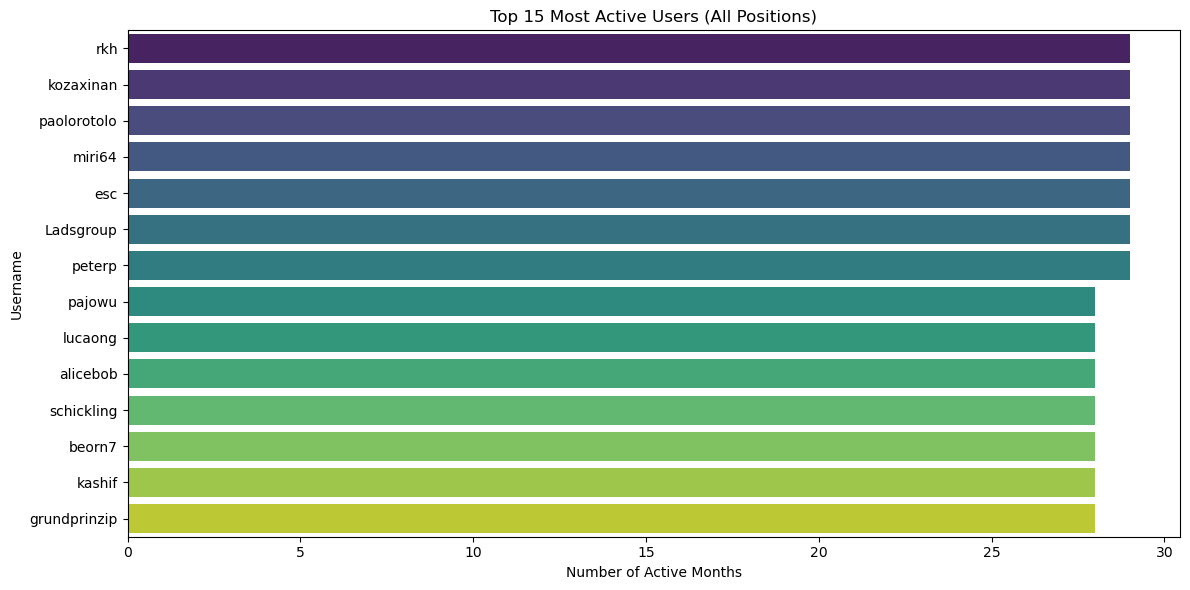

/var/folders/s4/jp6nyhdj3ks3855w2gjshb2c0000gn/T/ipykernel_53722/1000708661.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_users_pos, x="repo_month_count", y="username", ax=axes[i], palette="Set2")
/var/folders/s4/jp6nyhdj3ks3855w2gjshb2c0000gn/T/ipykernel_53722/1000708661.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_users_pos, x="repo_month_count", y="username", ax=axes[i], palette="Set2")
/var/folders/s4/jp6nyhdj3ks3855w2gjshb2c0000gn/T/ipykernel_53722/1000708661.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.

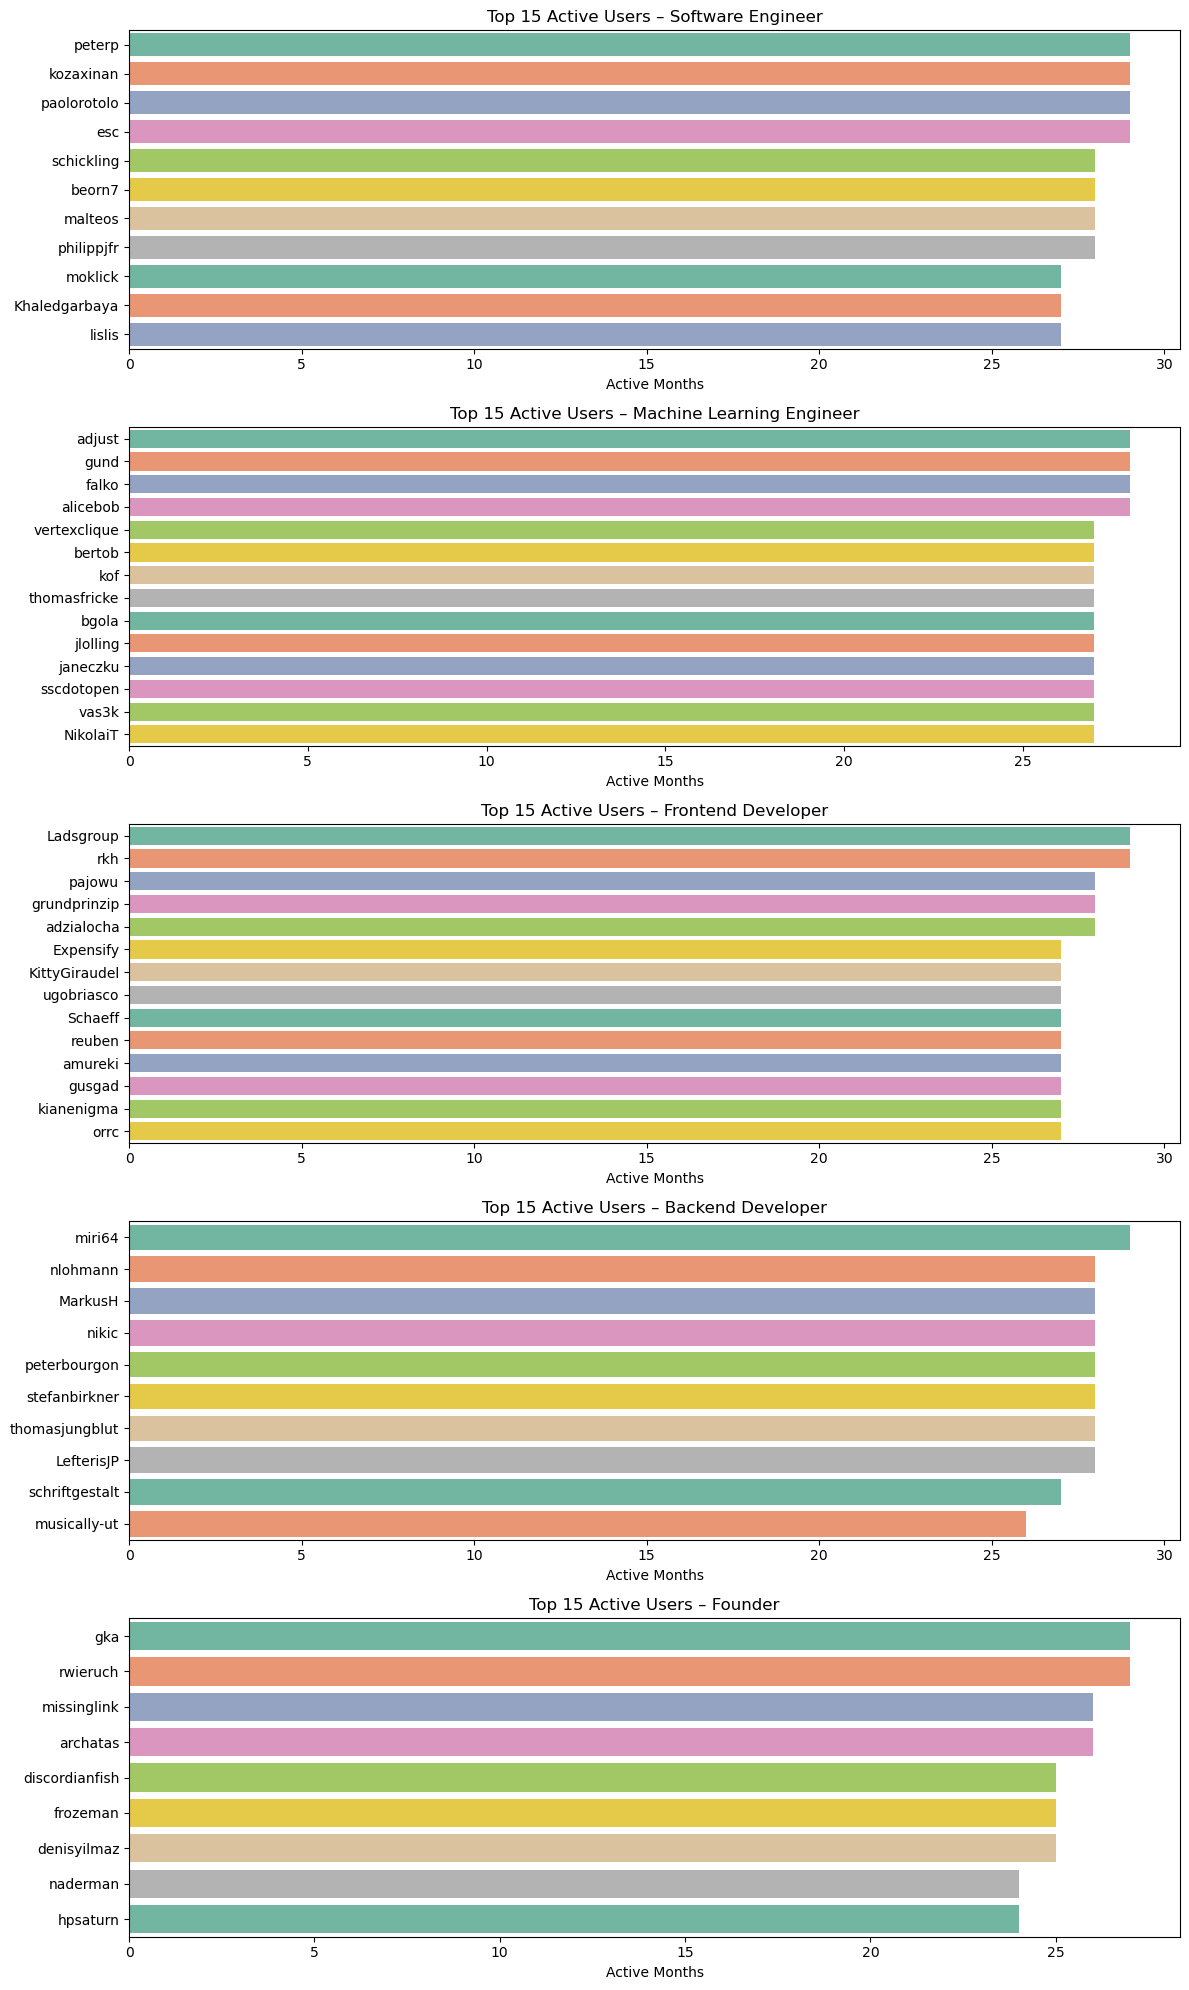

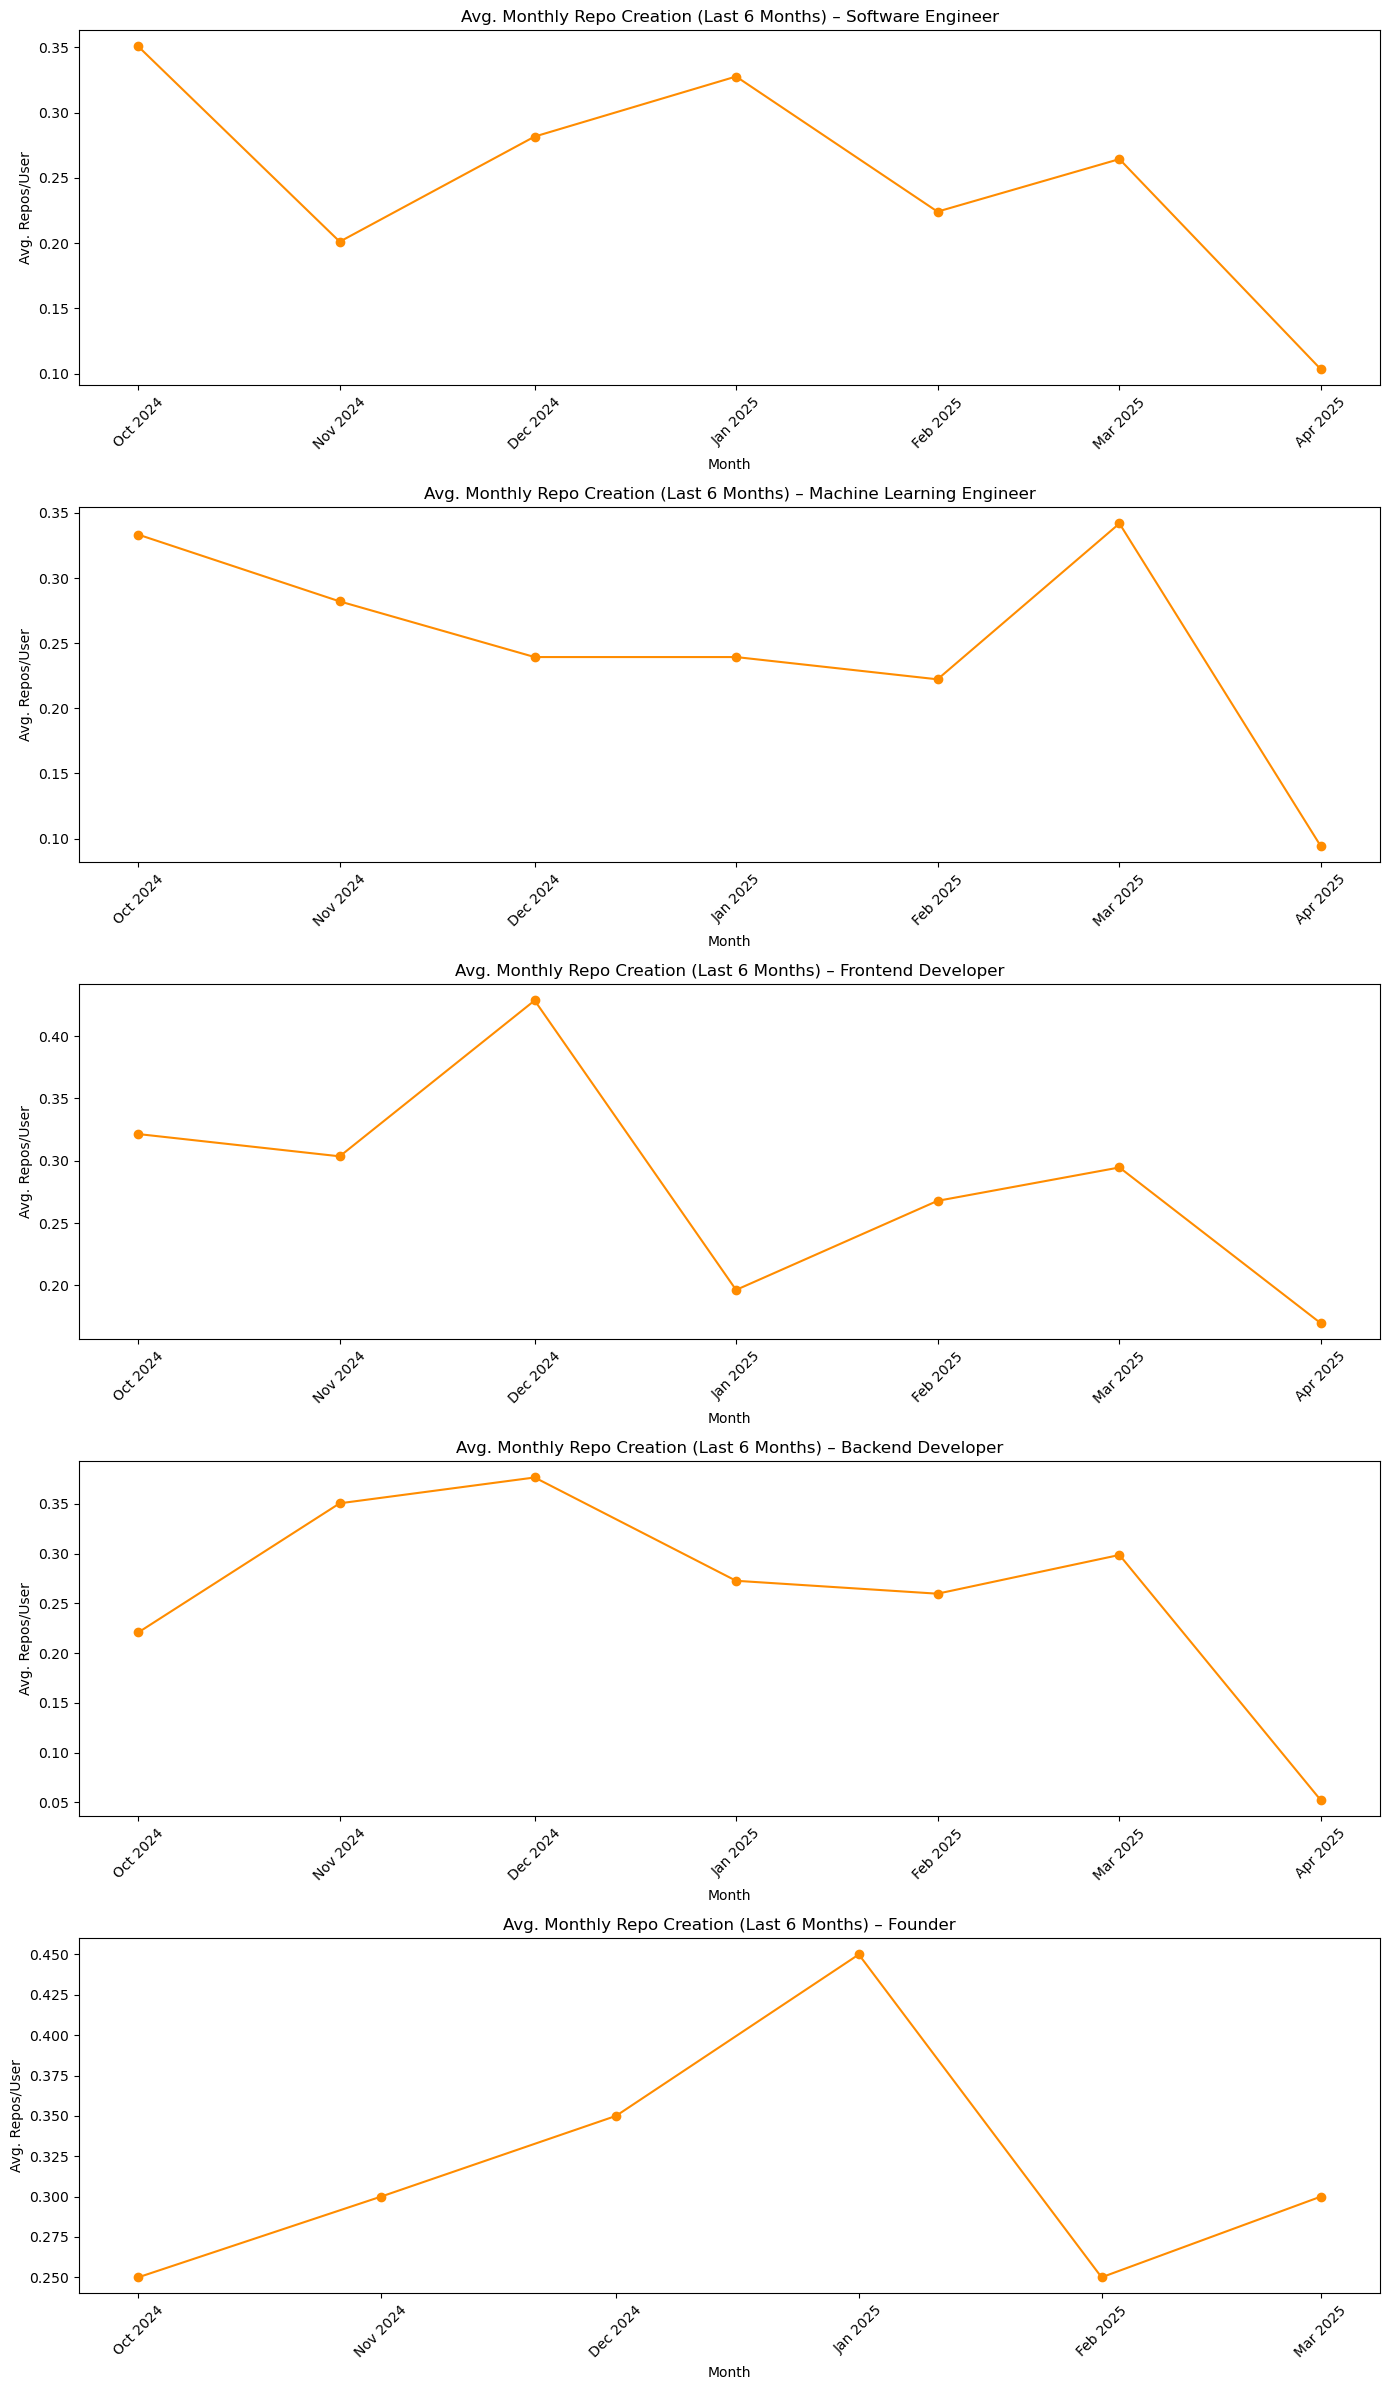

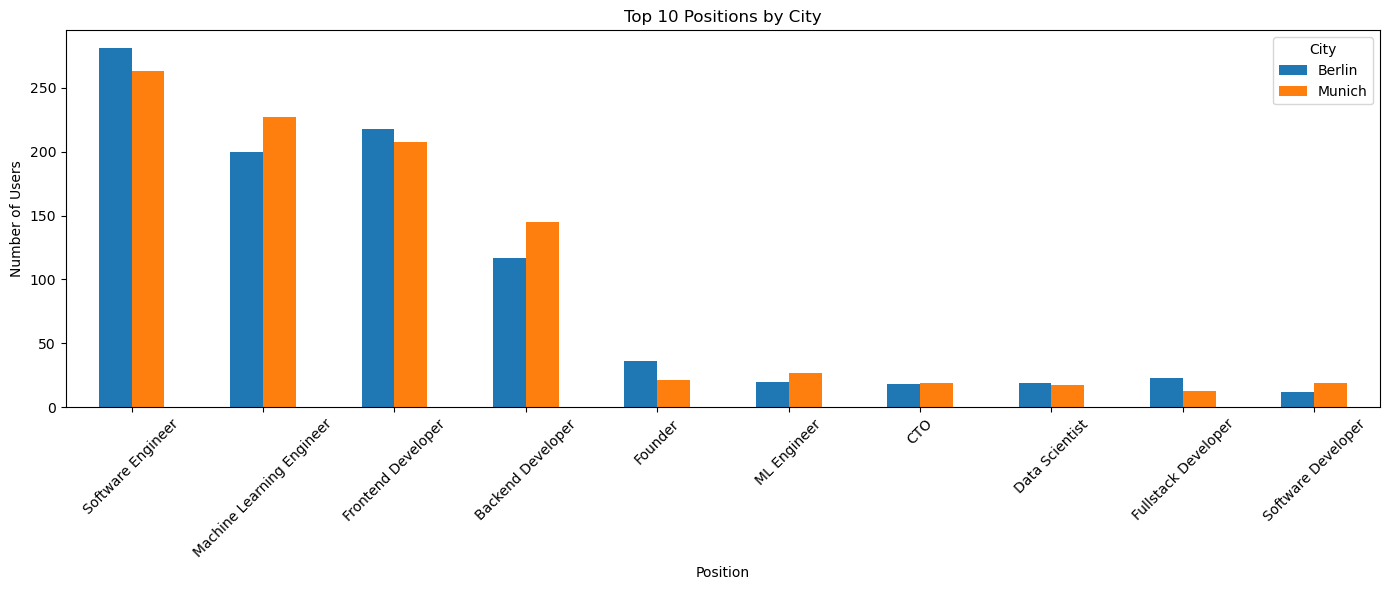

In [ ]:

# Top 5 positions by frequency
top_positions = df_valid["position_final"].value_counts().nlargest(5).index.tolist()



# TOP 15 ACTIVE USERS 
top_users = df_valid.sort_values(by="repo_month_count", ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x="repo_month_count", y="username", data=top_users, palette="viridis")
plt.title("Top 15 Most Active Users (All Positions)")
plt.xlabel("Number of Active Months")
plt.ylabel("Username")
plt.tight_layout()
plt.show()

# TOP 15 ACTIVE USERS PER POSITION 
fig, axes = plt.subplots(nrows=len(top_positions), figsize=(12, 20))
for i, pos in enumerate(top_positions):
    top_users_pos = df_valid[df_valid["position_final"] == pos] \
        .sort_values("repo_month_count", ascending=False).head(15)
    sns.barplot(data=top_users_pos, x="repo_month_count", y="username", ax=axes[i], palette="Set2")
    axes[i].set_title(f"Top 15 Active Users – {pos}")
    axes[i].set_xlabel("Active Months")
    axes[i].set_ylabel("")
plt.tight_layout()
plt.show()

# AVERAGE MONTHLY REPO
df_exploded = df_valid.explode("repo_months")
df_exploded["month_label"] = pd.to_datetime(df_exploded["repo_months"], errors="coerce")
df_exploded = df_exploded[df_exploded["month_label"].notna()]

cutoff_date = df_exploded["month_label"].max() - pd.DateOffset(months=6)
df_recent = df_exploded[df_exploded["month_label"] >= cutoff_date]

fig, axes = plt.subplots(nrows=len(top_positions), figsize=(14, 24))
for i, pos in enumerate(top_positions):
    subset = df_recent[df_recent["position_final"] == pos]
    if not subset.empty:
        monthly_counts = subset.groupby("month_label").size()
        monthly_avg = monthly_counts / subset["username"].nunique()
        monthly_avg = monthly_avg.sort_index()
        axes[i].plot(monthly_avg.index, monthly_avg.values, marker="o", color="darkorange")
        axes[i].set_title(f"Avg. Monthly Repo Creation (Last 6 Months) – {pos}")
        axes[i].set_ylabel("Avg. Repos/User")
        axes[i].set_xlabel("Month")
        axes[i].xaxis.set_major_formatter(DateFormatter("%b %Y"))
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].set_visible(False)
plt.tight_layout()
plt.show()

position_by_city = df_valid.groupby(["city", "position_final"]).size().unstack(fill_value=0)
top10_positions = position_by_city.sum().nlargest(10).index
city_grouped = position_by_city[top10_positions].T

city_grouped.plot(kind="bar", figsize=(14, 6))
plt.title("Top 10 Positions by City")
plt.ylabel("Number of Users")
plt.xlabel("Position")
plt.xticks(rotation=45)
plt.legend(title="City")
plt.tight_layout()
plt.show()
